### **Code: Checking WTP (Willingness To Pay)**
#### Writer : Donghyeon Kim
#### Update : 2025.08.29.

---


#### **0. Settings**


In [1]:
# Library
from pathlib import Path
import contextlib
import io
import os
import platform
import numpy as np
import pandas as pd
with contextlib.redirect_stderr(io.StringIO()):
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    from matplotlib import font_manager
    from matplotlib.ticker import StrMethodFormatter

# Python Options
pd.set_option("display.max_columns", 600)

# 그래프 한글 폰트
def set_korean_font() -> None:
    """운영체제에 맞는 한글 폰트를 Matplotlib에 적용"""
    system_name = platform.system()
    font_candidates = {
        "Darwin": ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic"],
        "Windows": ["NanumGothic", "Malgun Gothic"],
    }
    fallback_fonts = ["NanumGothic", "Noto Sans KR", "Noto Sans CJK KR", "Arial Unicode MS"]
    installed_fonts = {font.name for font in font_manager.fontManager.ttflist}

    for font_name in font_candidates.get(system_name, []) + fallback_fonts:
        if font_name in installed_fonts:
            mpl.rcParams["font.family"] = font_name
            break

    mpl.rcParams["axes.unicode_minus"] = False

set_korean_font()

In [2]:
# 경로 설정
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "2. Python Code" else NOTEBOOK_DIR

DATA_PATH = (
    PROJECT_ROOT
    / "1. Rawdata"
    / "1. 예비설문"
    / "1. 네이버폼(bid 설정 목적)"
    / "설문조사결과(3차)_250828.xlsx"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "3. Result"
    / "1. 예비설문"
    / "1. 네이버폼(bid 설정 목적)"
)
FIGURE_DPI = 300


COLUMN_NAMES = [
    "응답일시",
    "참여자",
    "성별",
    "나이",
    "소속기관",
    "직급",
    "지불의사금액"
]

EXCLUDED_PARTICIPANTS = range(1, 9)
MANUAL_OUTLIERS = [0, 9_900, 10_000_000]
BID_INFO = {
    "bid1": 120_000,
    "bid2": 360_000,
    "bid3": 600_000,
    "bid4": 840_000,
    "bid5": 1_200_000
}

---


#### **1. Data 로드 및 전처리**


In [3]:
def load_wtp_data(file_path: Path = DATA_PATH) -> pd.DataFrame:
    """예비설문 데이터를 불러오고 WTP를 숫자형으로 변환"""
    df = pd.read_excel(file_path)
    df.columns = COLUMN_NAMES

    df = df.loc[~df["참여자"].isin(EXCLUDED_PARTICIPANTS)].copy()
    df.insert(0, "row_id", np.arange(1, len(df) + 1))
    df["wtp"] = (
        df["지불의사금액"]
        .astype(str)
        .str.replace(r"[^0-9]", "", regex=True)
        .replace("", np.nan)
        .astype(float)
    )
    
    return df


def add_plot_id(df: pd.DataFrame, id_col: str = "plot_id") -> pd.DataFrame:
    """필터링된 데이터의 x축 표시용 연속 번호 추가"""
    result = df.copy()
    result[id_col] = np.arange(1, len(result) + 1)
    return result


wtp_df = load_wtp_data()
wtp_df.head()

,row_id,응답일시,참여자,성별,나이,소속기관,직급,지불의사금액,wtp
8,1,2025-08-20 14:06:10,9,여자,21~29세,기업,선임연구원,20000,20000.0
9,2,2025-08-20 14:09:19,10,남자,40~49세,"연구기관(출연(연), 국공립(연) 등)",책임연구원,100000,100000.0
10,3,2025-08-20 14:13:24,11,남자,40~49세,"연구기관(출연(연), 국공립(연) 등)",선임연구원,120000,120000.0
11,4,2025-08-20 14:13:49,12,남자,40~49세,"연구기관(출연(연), 국공립(연) 등)",책임연구원,0,0.0
12,5,2025-08-20 14:14:46,13,남자,50~59세,"연구기관(출연(연), 국공립(연) 등)",센터장,120000,120000.0


---


#### **2. WTP 요약 통계량**

In [4]:
def get_iqr_bounds(series: pd.Series) -> tuple[float, float]:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def summarize_wtp(series: pd.Series) -> pd.Series:
    clean = series.dropna()
    quantiles = clean.quantile([0, 0.25, 0.5, 0.75, 1])

    return pd.Series(
        {
            "n": len(clean),
            "mean": clean.mean(),
            "median": clean.median(),
            "min": quantiles.loc[0],
            "q1": quantiles.loc[0.25],
            "q3": quantiles.loc[0.75],
            "max": quantiles.loc[1],
        }
    )


wtp = wtp_df["wtp"]
iqr_lower, iqr_upper = get_iqr_bounds(wtp)

manual_trimmed_df = add_plot_id(
    wtp_df.loc[wtp_df["wtp"].notna() & ~wtp_df["wtp"].isin(MANUAL_OUTLIERS)]
)
iqr_trimmed_df = add_plot_id(
    wtp_df.loc[wtp_df["wtp"].between(iqr_lower, iqr_upper, inclusive="both")]
)

summary = pd.DataFrame(
    {
        "원자료 WTP": summarize_wtp(wtp),
        "수동 이상치 제거": summarize_wtp(manual_trimmed_df["wtp"]),
        "IQR 기준 이상치 제거": summarize_wtp(iqr_trimmed_df["wtp"]),
    }
).T

summary.round(1)

,n,mean,median,min,q1,q3,max
원자료 WTP,36.0,454441.7,119500.0,0.0,27500.0,185000.0,10000000.0
수동 이상치 제거,31.0,204838.7,120000.0,10000.0,99500.0,190000.0,1200000.0
IQR 기준 이상치 제거,31.0,98706.5,100000.0,0.0,16000.0,125000.0,360000.0


---


#### **3. WTP 간단 시각화**

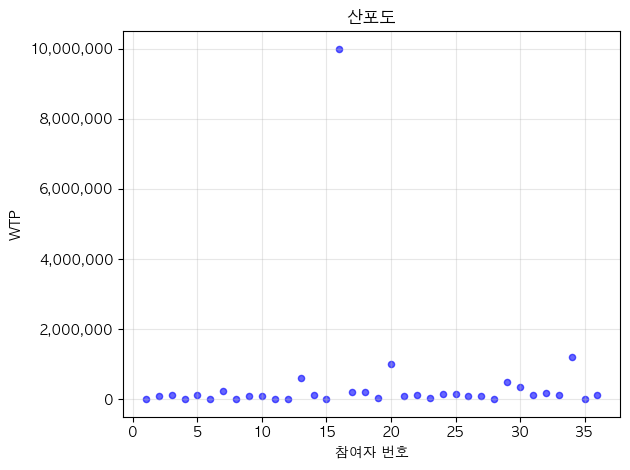

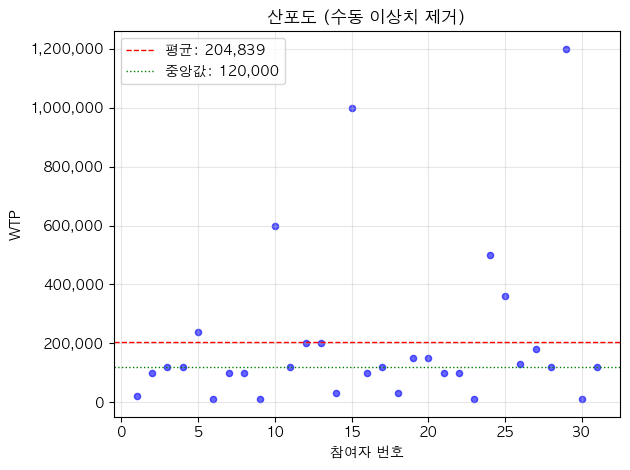

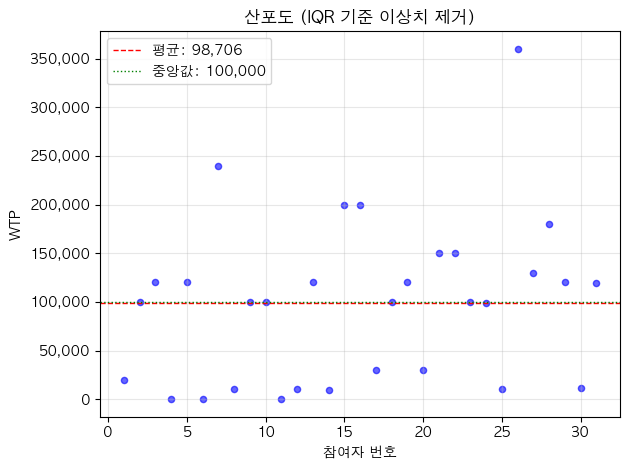

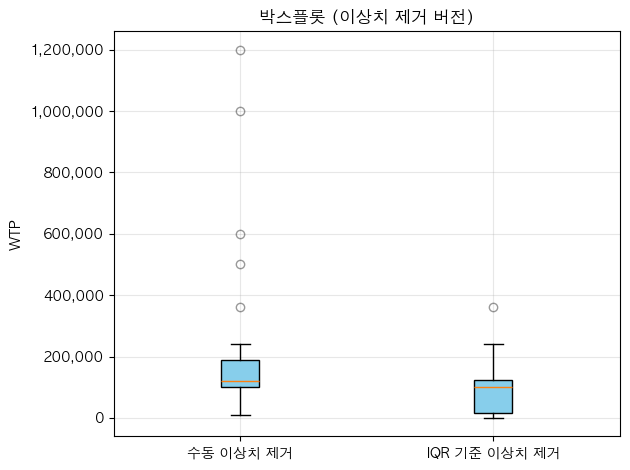

In [5]:
COMMA_FORMATTER = StrMethodFormatter("{x:,.0f}")

def save_wtp_figure(fig, file_name: str) -> None:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / file_name, dpi=FIGURE_DPI, bbox_inches="tight")


def format_wtp_axis(ax) -> None:
    ax.yaxis.set_major_formatter(COMMA_FORMATTER)
    ax.grid(True, alpha=0.3)


def plot_wtp_dispersion(
    df: pd.DataFrame,
    x_col: str,
    title: str,
    show_reference_lines: bool = False,
    save_as: str | None = None,
) -> None:
    fig, ax = plt.subplots()
    ax.scatter(df[x_col], df["wtp"], color="blue", alpha=0.6, s=20)

    if show_reference_lines:
        mean_wtp = df["wtp"].mean()
        median_wtp = df["wtp"].median()
        ax.axhline(mean_wtp, color="red", linestyle="--", linewidth=1, label=f"평균: {mean_wtp:,.0f}")
        ax.axhline(median_wtp, color="green", linestyle=":", linewidth=1, label=f"중앙값: {median_wtp:,.0f}")
        ax.legend()

    ax.set_title(title)
    ax.set_xlabel("참여자 번호")
    ax.set_ylabel("WTP")
    format_wtp_axis(ax)
    plt.tight_layout()
    if save_as:
        save_wtp_figure(fig, save_as)


def plot_wtp_boxplot(groups: dict[str, pd.Series], save_as: str | None = None) -> None:
    fig, ax = plt.subplots()
    boxplot = ax.boxplot(
        [series.dropna().values for series in groups.values()],
        tick_labels=list(groups.keys()),
        patch_artist=True,
    )

    for patch in boxplot["boxes"]:
        patch.set_facecolor("skyblue")
    for flier in boxplot["fliers"]:
        flier.set_alpha(0.4)

    ax.set_title("박스플롯 (이상치 제거 버전)")
    ax.set_xlabel("")
    ax.set_ylabel("WTP")
    format_wtp_axis(ax)
    plt.tight_layout()
    if save_as:
        save_wtp_figure(fig, save_as)


plot_wtp_dispersion(wtp_df, "row_id", "산포도", save_as="1_산포도_원본.png")

plot_wtp_dispersion(
    manual_trimmed_df,
    "plot_id",
    "산포도 (수동 이상치 제거)",
    show_reference_lines=True,
    save_as="2_산포도_극단값제거.png",
)

plot_wtp_dispersion(
    iqr_trimmed_df,
    "plot_id",
    "산포도 (IQR 기준 이상치 제거)",
    show_reference_lines=True,
    save_as="3_산포도_IQR극단값제거.png",
)

plot_wtp_boxplot(
    {
        "수동 이상치 제거": manual_trimmed_df["wtp"],
        "IQR 기준 이상치 제거": iqr_trimmed_df["wtp"],
    },
    save_as="4_Boxplot_극단값제거.png",
)